# Notebook complémentaire

## Seuils d'évaluation continue vs golden run

Distribution bootstrap de chaque métrique sur `data/reference_set.csv`,
comparée au golden run (`data/reference_baseline.json`) et aux seuils
définis dans `THRESHOLDS` (`scripts/evaluate_model.py`).

Légende des graphiques :

* histogramme des 2000 ré-échantillonnages bootstrap du jeu de référence (mesure le bruit de l'instrument) ;
* ligne verte = golden run, ligne violette = seuil (golden − tolérance), pointillés = ±2σ ;
* barres rouges = zone sous le seuil (fausses alertes) ;
* encadré : golden run, σ mesuré, 2σ recommandé, tolérance retenue, % de fausses alertes.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebook" else NOTEBOOK_DIR
sys.path.insert(0, str(ROOT / "scripts"))

import evaluate_model as em  # noqa: E402  (réutilise THRESHOLDS/compute_metrics du script réel)

model = joblib.load(em.MODELS_DIR / "pyrenex_risk_v2.joblib")
meta = json.loads((em.MODELS_DIR / "pyrenex_risk_v2.json").read_text(encoding="utf-8"))
reference_df = em.load_reference_set()
golden_run = json.loads(em.REFERENCE_BASELINE.read_text(encoding="utf-8"))

n_reference = len(reference_df)
n_default = int((reference_df[meta["target_column"]].map(meta["target_mapping"]) == 1).sum())
print(f"jeu de référence : {n_reference} lignes, {n_default} défauts ({n_default / n_reference:.0%})")
print(json.dumps(golden_run, indent=2))

jeu de référence : 500 lignes, 90 défauts (18%)
{
  "model_version": "v2.0.0",
  "reference_set": "data\\reference_set.csv",
  "n_reference": 500,
  "f1_macro": 0.5934178038647486,
  "f1_default": 0.4169611307420495,
  "roc_auc": 0.7247967479674797,
  "recall_default": 0.6555555555555556
}


In [2]:
N_BOOTSTRAP = 2000
rng = np.random.default_rng(42)

# ré-échantillonnage avec remise du jeu de référence -> mesure le bruit de l'instrument
bootstrap_metrics = {name: np.empty(N_BOOTSTRAP) for name in em.THRESHOLDS}
for i in range(N_BOOTSTRAP):
    resample = reference_df.sample(n=n_reference, replace=True, random_state=int(rng.integers(0, 2**32 - 1)))
    resample_metrics = em.compute_metrics(model, resample, meta)
    for name in em.THRESHOLDS:
        bootstrap_metrics[name][i] = resample_metrics[name]

print(f"{N_BOOTSTRAP} ré-échantillonnages bootstrap calculés pour {list(em.THRESHOLDS)}")

2000 ré-échantillonnages bootstrap calculés pour ['f1_macro', 'f1_default', 'roc_auc', 'recall_default']


Matplotlib is building the font cache; this may take a moment.


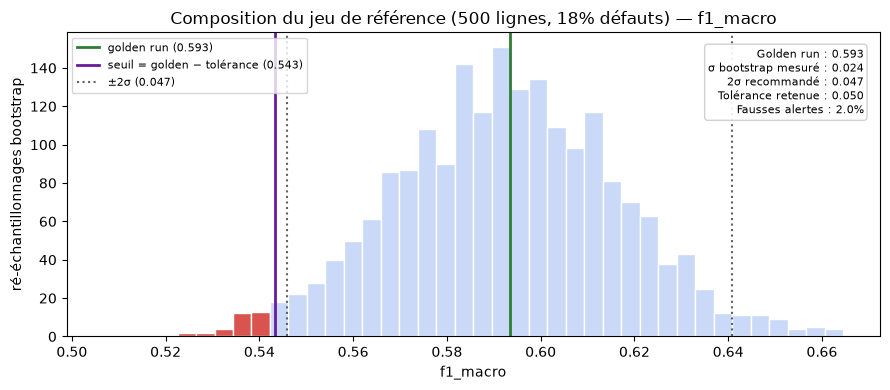

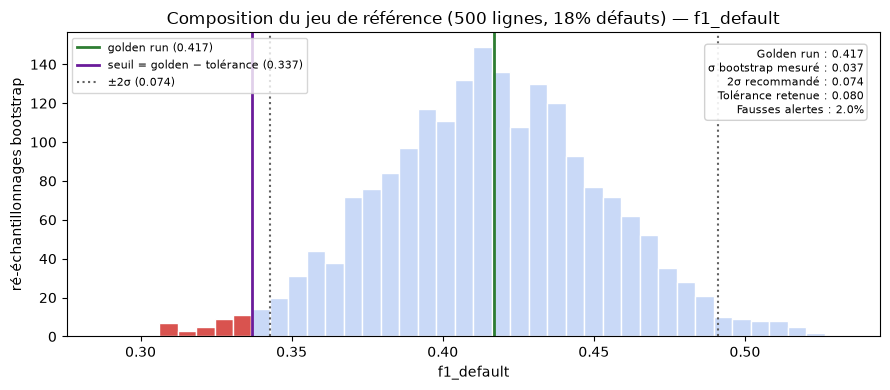

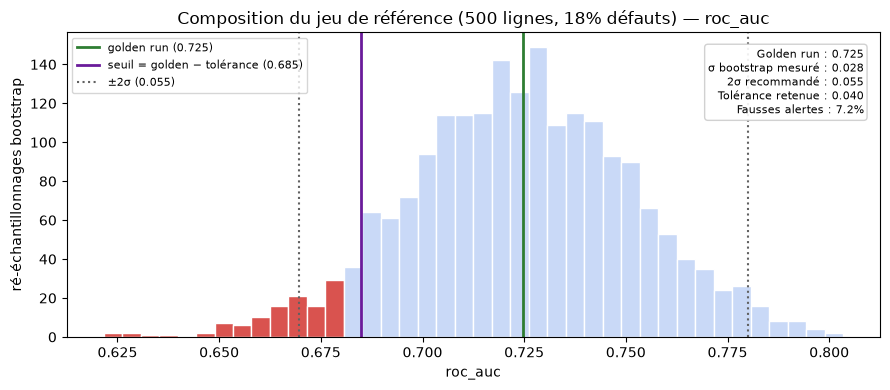

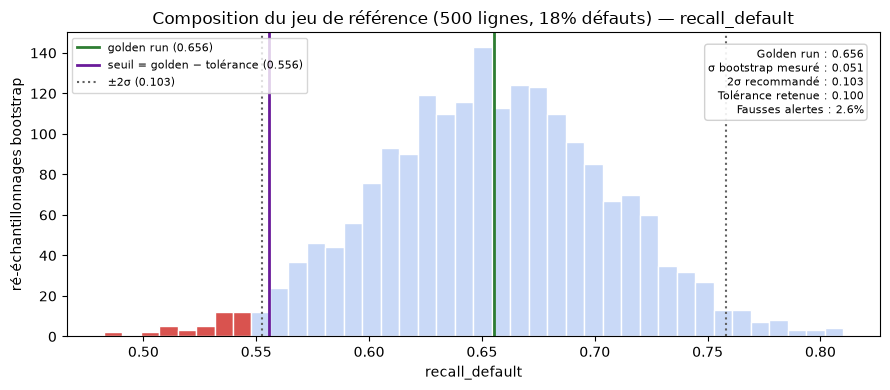

In [3]:
import matplotlib.pyplot as plt


def plot_threshold(metric_name: str) -> None:
    """Histogramme bootstrap d'une métrique vs golden run, seuil et bande ±2σ."""
    values = bootstrap_metrics[metric_name]
    golden = golden_run[metric_name]
    tolerance = em.THRESHOLDS[metric_name]["max_drop_vs_baseline"]
    seuil = golden - tolerance
    sigma = values.std(ddof=1)
    two_sigma = 2 * sigma
    false_alerts_pct = (values < seuil).mean() * 100

    fig, ax = plt.subplots(figsize=(9, 4))
    counts, bins, patches = ax.hist(values, bins=40, color="#c9d9f7", edgecolor="white")
    for right, patch in zip(bins[1:], patches):
        if right <= seuil:
            patch.set_facecolor("#d9534f")  # sous le seuil = fausse alerte

    ax.axvline(golden, color="#2e7d32", linewidth=2, label=f"golden run ({golden:.3f})")
    ax.axvline(seuil, color="#6a1b9a", linewidth=2, label=f"seuil = golden − tolérance ({seuil:.3f})")
    ax.axvline(golden - two_sigma, color="#616161", linestyle=":", label=f"±2σ ({two_sigma:.3f})")
    ax.axvline(golden + two_sigma, color="#616161", linestyle=":")

    ax.set_title(f"Composition du jeu de référence ({n_reference} lignes, {n_default / n_reference:.0%} défauts) — {metric_name}")
    ax.set_xlabel(metric_name)
    ax.set_ylabel("ré-échantillonnages bootstrap")
    ax.legend(loc="upper left", fontsize=8)

    info = (
        f"Golden run : {golden:.3f}\n"
        f"σ bootstrap mesuré : {sigma:.3f}\n"
        f"2σ recommandé : {two_sigma:.3f}\n"
        f"Tolérance retenue : {tolerance:.3f}\n"
        f"Fausses alertes : {false_alerts_pct:.1f}%"
    )
    ax.text(
        0.98, 0.95, info, transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc", alpha=0.9),
    )

    plt.tight_layout()
    plt.show()


for metric_name in em.THRESHOLDS:
    plot_threshold(metric_name)

In [4]:
for name in em.THRESHOLDS:
    sigma = bootstrap_metrics[name].std(ddof=1)
    tolerance = em.THRESHOLDS[name]["max_drop_vs_baseline"]
    print(f"{name:15s} golden={golden_run[name]:.4f}  sigma={sigma:.4f}  2sigma={2*sigma:.4f}  tolerance={tolerance:.4f}")

f1_macro        golden=0.5934  sigma=0.0237  2sigma=0.0475  tolerance=0.0500
f1_default      golden=0.4170  sigma=0.0371  2sigma=0.0742  tolerance=0.0800
roc_auc         golden=0.7248  sigma=0.0276  2sigma=0.0553  tolerance=0.0400
recall_default  golden=0.6556  sigma=0.0514  2sigma=0.1028  tolerance=0.1000


In [5]:
for name in em.THRESHOLDS:
    tolerance = em.THRESHOLDS[name]["max_drop_vs_baseline"]
    seuil = golden_run[name] - tolerance
    false_alerts_pct = (bootstrap_metrics[name] < seuil).mean() * 100
    print(f"{name:15s} seuil={seuil:.4f}  fausses_alertes={false_alerts_pct:.1f}%")

f1_macro        seuil=0.5434  fausses_alertes=2.0%
f1_default      seuil=0.3370  fausses_alertes=2.0%
roc_auc         seuil=0.6848  fausses_alertes=7.2%
recall_default  seuil=0.5556  fausses_alertes=2.6%


Remarque sur le ROC_AUC : 
la tolérance actuelle sur roc_auc (0.040) est sous le 2σ mesuré (0.055) → ~7.2% de fausses alertes, le seuil de tolérance a la référence a donc été abaissé à 0.4

## ML Flow

Après plusieurs essais et notamment un --degrade, on constate sur l'interface de MLFlow :
```bash
mlflow ui
```

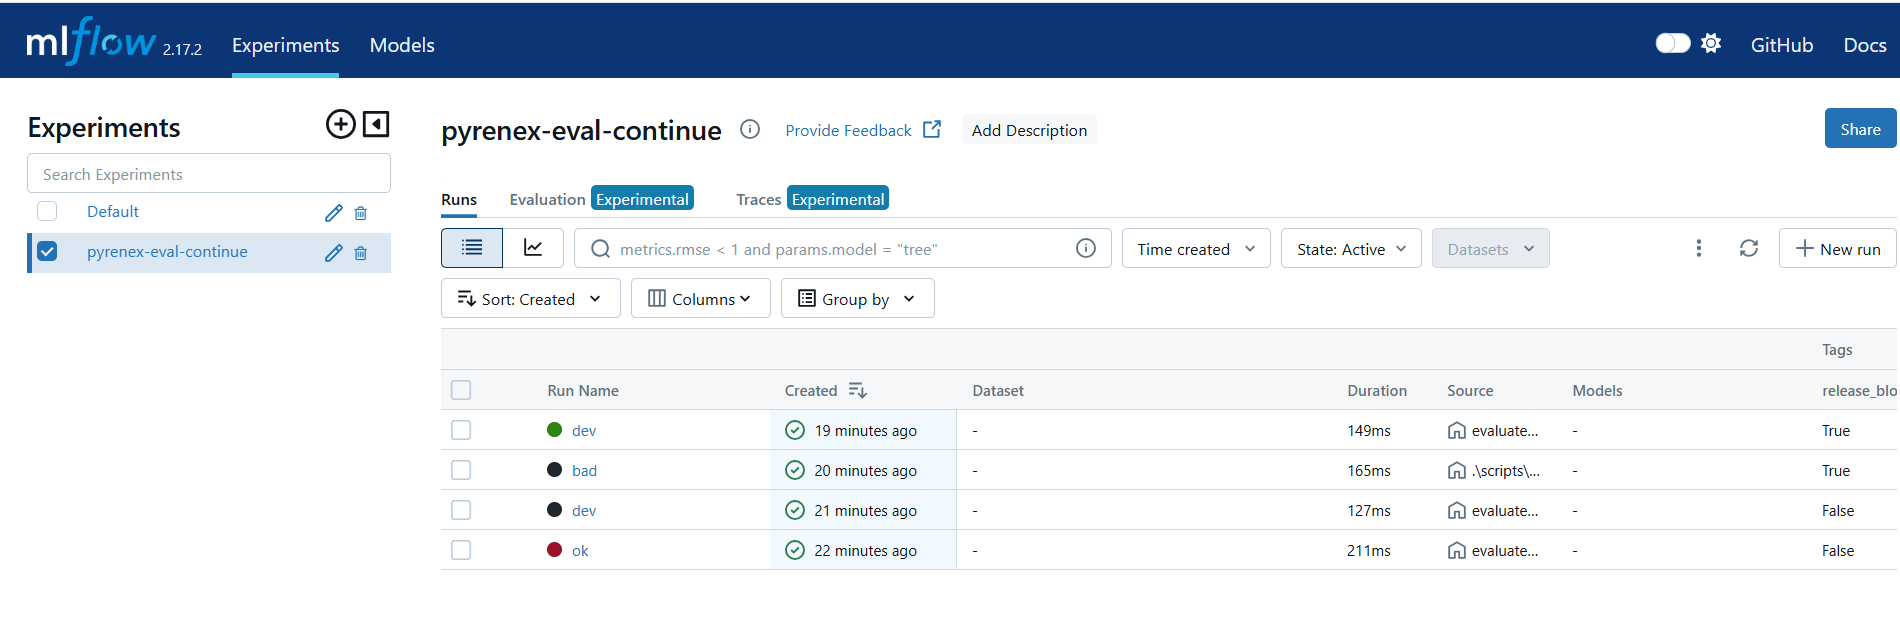